In [1728]:
import sys
!{sys.executable} -m pip install mlxtend
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_white

In [1729]:
df = pd.read_csv('../data/data_regression.csv', sep=';', decimal=',')
print(df.head())
print(df.describe())

                Регионы         Y   X1    X2     X3     X4    X5    X6
0  Белгородская область  643774.4  4.9  65.4  17.40  57.19 -3649  0.60
1      Брянская область  349774.4  4.0  69.5  16.02  33.66 -1588  0.57
2  Владимирская область  404785.5  5.6  77.7  15.83  33.43 -3588  0.59
3   Воронежская область  456565.5  4.3  68.3  19.87  46.21  4392  0.55
4    Ивановская область  284826.2  5.4  81.8  16.16  15.34  -772  0.62
                  Y         X1          X2         X3          X4  \
count  8.700000e+01  87.000000   87.000000  87.000000   87.000000   
mean   5.534269e+05   6.993103   70.912299  16.833793   62.251264   
std    4.257742e+05   4.145768   12.873592   2.690030  107.669111   
min    1.416183e+05   2.400000   30.900000  10.730000    0.990000   
25%    3.334825e+05   4.850000   64.150000  15.270000   11.070000   
50%    4.565655e+05   5.900000   72.400000  16.770000   30.590000   
75%    5.808766e+05   7.600000   78.050000  18.090000   45.340000   
max    2.495514e+06  3

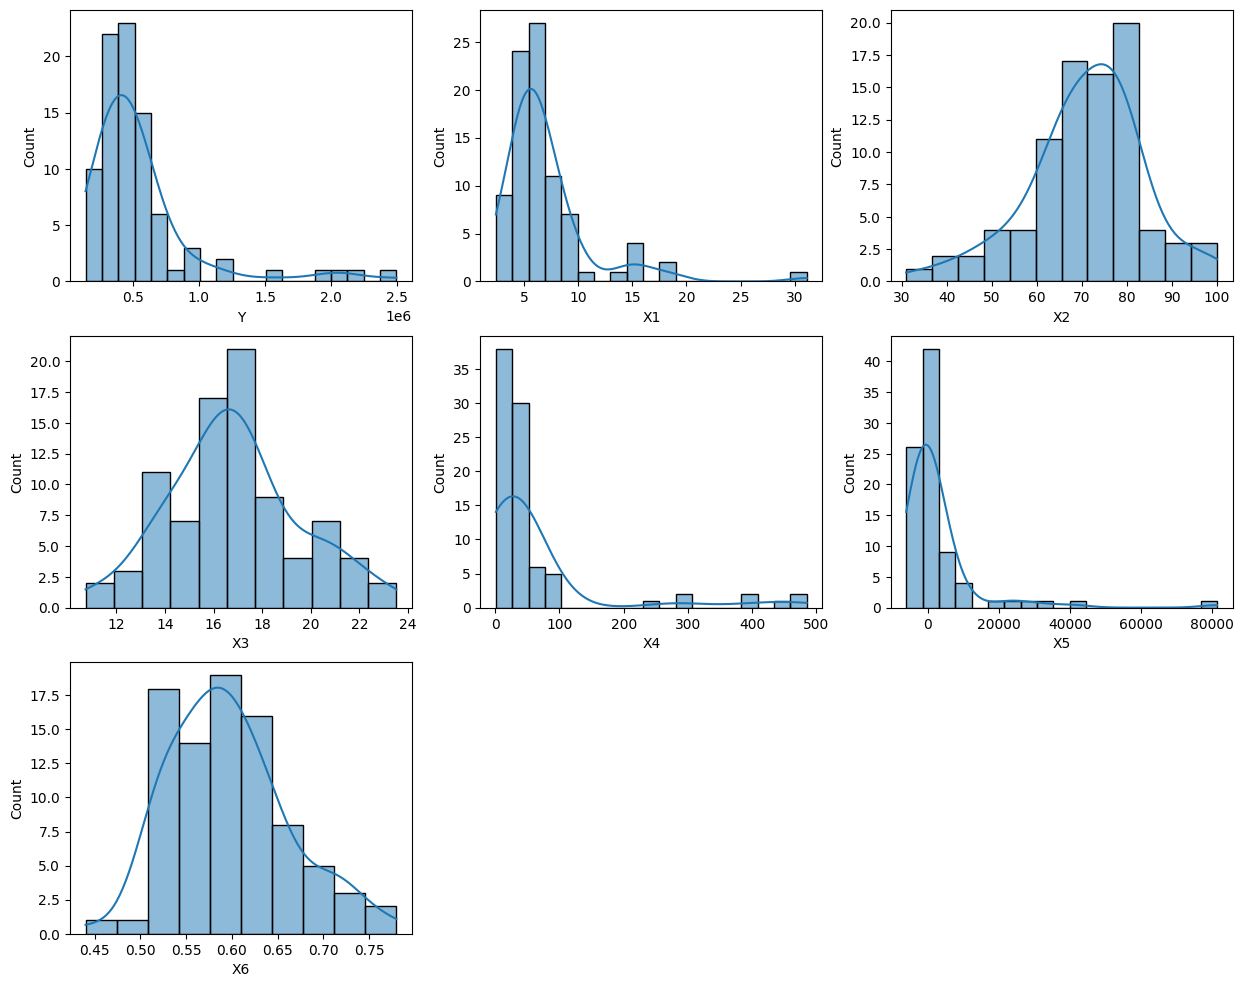

In [1730]:
cols = df.columns[1:] 
plt.figure(figsize=(15, 12)) 
for i, col in enumerate(cols, 1): 
    plt.subplot(3, 3, i) 
    sns.histplot(df[col], kde=True) 
plt.show()

Для ряда показателей (ВРП на душу населения(Y), заболеваемость(X4), миграционный поток(X5)) визуально заметны выраженные правосторонние хвосты и наличие отдельных аномально высоких наблюдений. Это указывает на существенную неоднородность данных и необходимость логарифмического преобразования для стабилизации дисперсии и уменьшения влияния выбросов.

### Расмотрим наличие выбросов детельнее

In [1731]:
mean_val = df['Y'].mean()
std_val = df['Y'].std()
print(f"Среднее (M): {mean_val}")
print(f"Станд. отклонение (sigma): {std_val}")

# стандартизация
df['z_manual'] = (df['Y'] - mean_val) / std_val
outliers = df[df['z_manual'].abs() > 2]

print(f"Найдено выбросов: {len(outliers)}")
print(outliers[['Регионы', 'Y']])

Среднее (M): 553426.9275862069
Станд. отклонение (sigma): 425774.22703070473
Найдено выбросов: 5
                       Регионы          Y
17                    г.Москва  1562963.6
61           Тюменская область  1923636.2
83         Магаданская область  2066380.4
84         Сахалинская область  2124645.0
86  Чукотский автономный округ  2495513.7


Дополнительно из выборки исключим г. Санкт-Петербург, Ненецкий АО, Тюменскую область в тч Ямало Ненецкий АО. Учитывая фокус модели на человеческих ресурсах, данные регионы признаны структурными аномалиями: в автономных округах ВРП формируется преимущественно за счет природной ренты и вахтового труда, а в Санкт-Петербурге — за счет агломерационного эффекта и концентрации штаб-квартир корпораций, что искажает реальную связь между показателями населения и экономическим выходом.

In [1732]:
all_outliers = outliers.index.tolist() + [21, 22, 29, 62, 63]
df_clean = df.drop(index=all_outliers)
print(f"Количество регионов до очистки: {len(df)}")
print(f"Количество регионов после очистки: {len(df_clean)}")
print("\nУдаленные регионы:")
print(df.loc[all_outliers, ['Регионы', 'Y']])

Количество регионов до очистки: 87
Количество регионов после очистки: 77

Удаленные регионы:
                                             Регионы          Y
17                                          г.Москва  1562963.6
61                                 Тюменская область  1923636.2
83                               Магаданская область  2066380.4
84                               Сахалинская область  2124645.0
86                        Чукотский автономный округ  2495513.7
21                        в т.ч. Ненецкий авт. округ   198653.5
22    Архангельская область без Ненецкого авт.округа   548518.4
29                                 г.Санкт-Петербург   954862.8
62     в т.ч. Ханты-Мансийский автономный округ-Югра   197598.9
63                   Ямало-Ненецкий автономный округ   243308.8


Чтобы отмасштабировать данные, переведём ВРП в миллионы рублей, а миграцию – в тысячи человек. 

In [1733]:
df_clean['X5_thous'] = df_clean['X5'] / 1000
df_clean['Y_mln'] = df_clean['Y'] / 1000000
df_clean = df_clean.drop(columns = ['Y', 'X5', 'z_manual'])
cols = df_clean.columns.tolist()
new_cols = [cols[0], cols[-1]] + cols[1:5]+ [cols[6]] + [cols[5]]
df_clean = df_clean[new_cols]
print(df_clean.head(20))

                  Регионы     Y_mln   X1    X2     X3      X4  X5_thous    X6
0    Белгородская область  0.643774  4.9  65.4  17.40   57.19    -3.649  0.60
1        Брянская область  0.349774  4.0  69.5  16.02   33.66    -1.588  0.57
2    Владимирская область  0.404786  5.6  77.7  15.83   33.43    -3.588  0.59
3     Воронежская область  0.456566  4.3  68.3  19.87   46.21     4.392  0.55
4      Ивановская область  0.284826  5.4  81.8  16.16   15.34    -0.772  0.62
5       Калужская область  0.533060  4.7  75.0  18.75  295.25     3.448  0.63
6     Костромская область  0.343868  5.5  73.4  14.22   35.46    -1.263  0.65
7         Курская область  0.477363  4.8  68.4  17.32   23.09     1.691  0.60
8        Липецкая область  0.535238  4.3  63.3  17.89   24.13    -1.743  0.61
9      Московская область  0.643208  3.6  78.7  23.52    9.58    81.305  0.55
10      Орловская область  0.389874  6.1  66.7  19.26    1.71    -1.470  0.61
11      Рязанская область  0.413598  5.3  71.5  15.24  445.88   

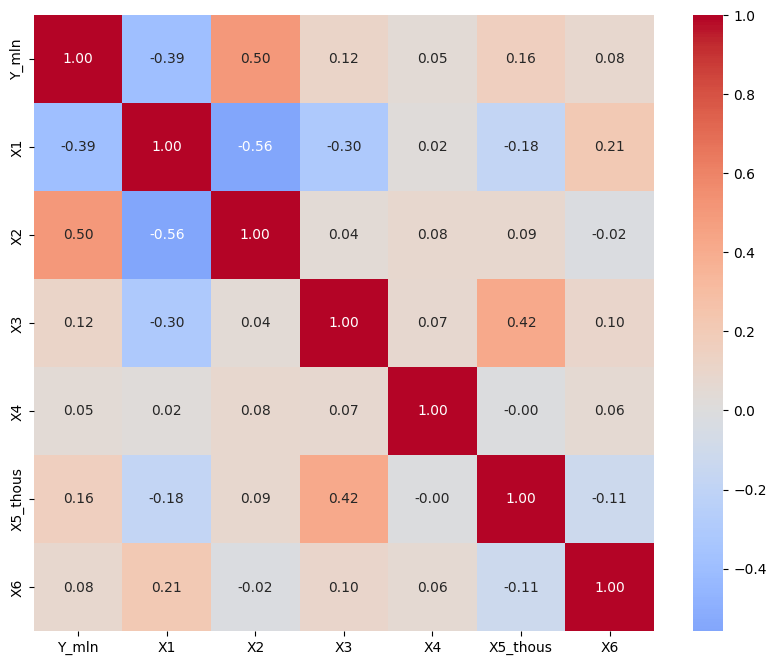

           Y_mln         X1
count  77.000000  77.000000
mean    0.465351   7.297403
std     0.200564   4.252862
min     0.141618   3.600000
25%     0.335560   5.000000
50%     0.413598   6.000000
75%     0.540722   7.700000
max     1.164918  31.100000


In [1734]:
corr_matrix = df_clean.drop(columns=['Регионы']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0) 
plt.show()
print(df_clean[['Y_mln', 'X1']].describe())

Мультиколинеарности нет

In [1735]:
factors = ['X1', 'X2', 'X3', 'X4', 'X5_thous', 'X6']
target = df_clean['Y_mln']

while len(factors) > 0:
    X = sm.add_constant(df_clean[factors])
    model = sm.OLS(target, X).fit()
    p_values = model.pvalues.drop('const')
    max_p = p_values.max()
    
    if max_p > 0.05:
        excluded_feature = p_values.idxmax()
        print(f"Исключаем фактор '{excluded_feature}' с p-value = {max_p:.4f}")
        factors.remove(excluded_feature)
    else:
        break
print(model.summary())

Исключаем фактор 'X4' с p-value = 0.8979
Исключаем фактор 'X3' с p-value = 0.8426
Исключаем фактор 'X5_thous' с p-value = 0.2633
Исключаем фактор 'X6' с p-value = 0.1905
Исключаем фактор 'X1' с p-value = 0.1825
                            OLS Regression Results                            
Dep. Variable:                  Y_mln   R-squared:                       0.252
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     25.30
Date:                Fri, 01 May 2026   Prob (F-statistic):           3.25e-06
Time:                        14:33:16   Log-Likelihood:                 26.148
No. Observations:                  77   AIC:                            -48.30
Df Residuals:                      75   BIC:                            -43.61
Df Model:                           1                                         
Covariance Type:            nonrobust                                         

Получившаяся модель включает в себя всего один фактор, ее объясняющая способность всего 25%. Проведем тест Уайта и построим график для проверки остатков на гомоскедастичность

{'Test Statistic': np.float64(6.900513525795822), 'Test Statistic p-value': np.float64(0.03173748632283614), 'F-Statistic': np.float64(3.6422378150858465), 'F-Test p-value': np.float64(0.030995034091326482)}


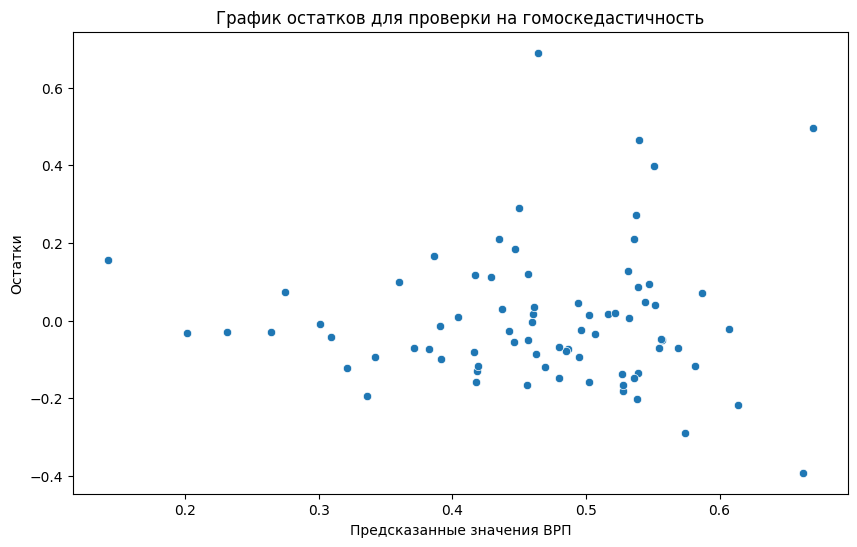

In [1736]:
labels = ['Test Statistic', 'Test Statistic p-value', 'F-Statistic', 'F-Test p-value']
white_test = het_white(model.resid, model.model.exog)
print(dict(zip(labels, white_test)))

fitted_vals = model.fittedvalues # предсказания у
residuals = model.resid # остатки
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_vals, y=residuals)
plt.xlabel('Предсказанные значения ВРП')
plt.ylabel('Остатки')
plt.title('График остатков для проверки на гомоскедастичность')
plt.show()

Поскольку тест Уайта подтвердил наличие гетероскедастичности p < 0,05, визуальный анализ остатков также выявил характерное расширение их дисперсии при росте прогнозных значений ВРП. Логарифмируем целевую переменную. Данный переход к модели вида lnY является стандартной практикой при анализе региональных данных с существенным разбросом масштабов экономики, так как он позволяет стабилизировать дисперсию ошибок, нормализовать распределение данных и перейти к интерпретации коэффициентов через показатели эластичности.

In [1737]:
df_clean['ln_Y'] = np.log(df_clean['Y_mln'])
df_clean = df_clean.drop(columns = ['Y_mln'])
print(df_clean.head())


                Регионы   X1    X2     X3     X4  X5_thous    X6      ln_Y
0  Белгородская область  4.9  65.4  17.40  57.19    -3.649  0.60 -0.440407
1      Брянская область  4.0  69.5  16.02  33.66    -1.588  0.57 -1.050467
2  Владимирская область  5.6  77.7  15.83  33.43    -3.588  0.59 -0.904398
3   Воронежская область  4.3  68.3  19.87  46.21     4.392  0.55 -0.784023
4    Ивановская область  5.4  81.8  16.16  15.34    -0.772  0.62 -1.255876


Так как целевая переменная была трансформировано, посмотрим еще раз на матрицу корреляций

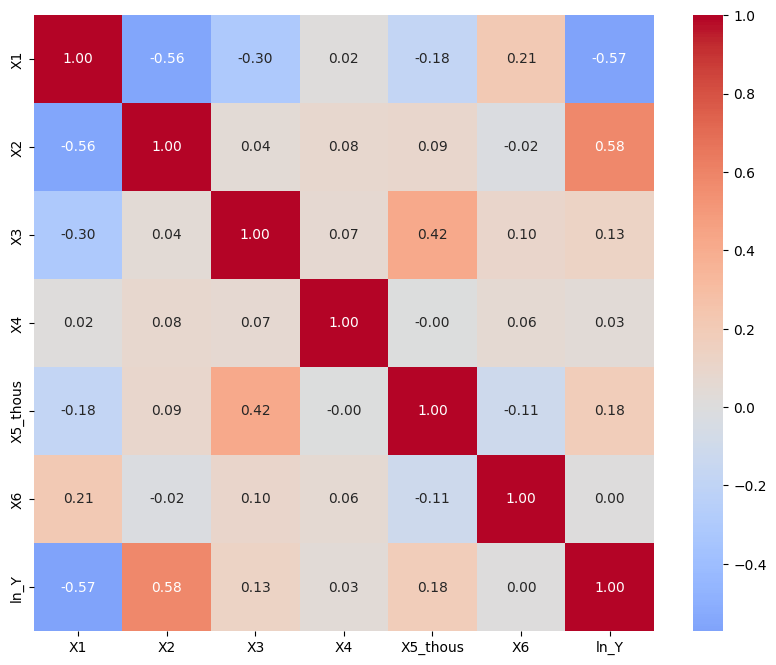

In [1738]:
corr_matrix = df_clean.drop(columns=['Регионы']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.show()

Коэффициенты корреляции оказались умеренными: ни одна пара факторов не показывает слишком сильной зависимости (обычно проблемой считаются значения выше 0,7). Это означает, что переменные можно одновременно включать в регрессию – они не «дублируют» друг друга и несут самостоятельную информацию.

Для оценки статистической значимости коэффициентов парной корреляции проверим гипотезы для каждого из них. На практике используется t-тест значимости коэффициента корреляции r_xy, основанный на распределении Стьюдента. Проверяются следующие гипотезы: H_0: ρ_xy=0 H_1: ρ_xy≠0. Если соответствующее p-значение меньше уровня значимости α=0,05 нулевая гипотеза отвергается и коэффициент корреляции считается статистически значимым.


In [1739]:

factors_list = ['X1', 'X2', 'X3', 'X4', 'X5_thous', 'X6']
df_corr_test = df_clean[factors_list] # без названий регионов

results = []
n = len(df_corr_test) 
df = n - 2

t_crit = stats.t.ppf(1 - 0.05/2, df) # t критическое

for i in range(len(factors_list)):
    for j in range(i + 1, len(factors_list)):
        f1, f2 = factors_list[i], factors_list[j]
        r, p_val = stats.pearsonr(df_corr_test[f1], df_corr_test[f2])
        
        # t-наблюдаемое
        t_obs = r * np.sqrt(df / (1 - r**2))
        
        results.append({
            'Пара': f'{f1}-{f2}',
            't_набл': round(t_obs, 4),
            't_крит': round(t_crit, 2),
            'p-значение': round(p_val, 6),
            'Проверка': 'Значим' if p_val < 0.05 else 'Не значим'
        })

pd.DataFrame(results)

,Пара,t_набл,t_крит,p-значение,Проверка
0,X1-X2,-5.8266,1.99,0.000000,Значим
1,X1-X3,-2.7682,1.99,0.007097,Значим
2,X1-X4,0.1388,1.99,0.889977,Не значим
3,X1-X5_thous,-1.5984,1.99,0.114148,Не значим
4,X1-X6,1.8622,1.99,0.066488,Не значим
5,X2-X3,0.3771,1.99,0.707196,Не значим
6,X2-X4,0.7357,1.99,0.464215,Не значим
7,X2-X5_thous,0.7460,1.99,0.458017,Не значим
8,X2-X6,-0.1774,1.99,0.859705,Не значим
9,X3-X4,0.6026,1.99,0.548604,Не значим


Мы проверяли связи «один на один», чтобы понять структуру данных, но ничего не удаляем сразу. Окончательную чистку сделает регрессия: она оценит влияние каждого фактора в связке с остальными. Если какой-то X реально бесполезен, он вылетит позже сам по p-value. Сейчас мы просто подтверждаем, что в данных есть системные зависимости, а не случайный шум.

In [1740]:
# Округляем целевую переменную до 4 знаков
df_clean['ln_Y'] = df_clean['ln_Y'].round(4)

# Сохраняем файл 
df_clean.to_csv('../data/regression_data_final.csv', index=False, encoding='utf-8-sig', sep=';')
